# Tesla Sales and Deliveries ML Pipeline

This notebook builds a simple end-to-end machine learning pipeline using Tesla deliveries and production data. The main steps include data understanding, EDA, feature engineering, model training, evaluation, and basic trend analysis.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


# Loading the Dataset


In [3]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

print("Dataset loaded successfully")
df.head()

Dataset loaded successfully


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


# Understanding the Dataset


In [4]:
print("Shape of Dataset:", df.shape)

print("\nColumn Names:\n")
print(df.columns)

Shape of Dataset: (2640, 12)

Column Names:

Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')


# Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


# Statistical Summary

In [6]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


# Checking Missing Values

In [7]:
df.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


### Observation

The dataset contains information related to Tesla vehicle production, deliveries, pricing, battery capacity, charging stations, and environmental impact. Most of the columns are numerical and useful for regression analysis and trend analysis.

# Exploratory Data Analysis (EDA)

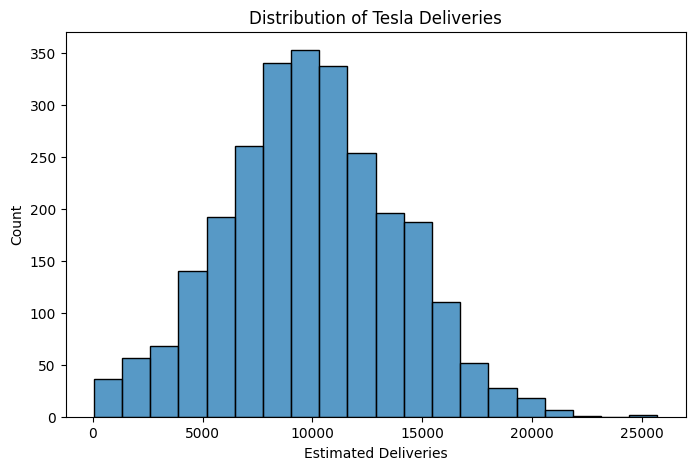

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df['Estimated_Deliveries'], bins=20)

plt.title("Distribution of Tesla Deliveries")
plt.xlabel("Estimated Deliveries")
plt.ylabel("Count")

plt.show()

### Production Units vs Estimated Deliveries

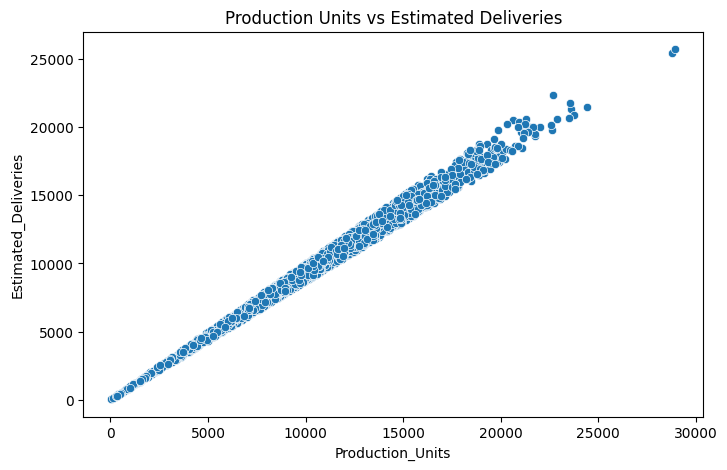

In [9]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['Production_Units'],
    y=df['Estimated_Deliveries']
)

plt.title("Production Units vs Estimated Deliveries")

plt.show()

### Correlation Between Numerical Features

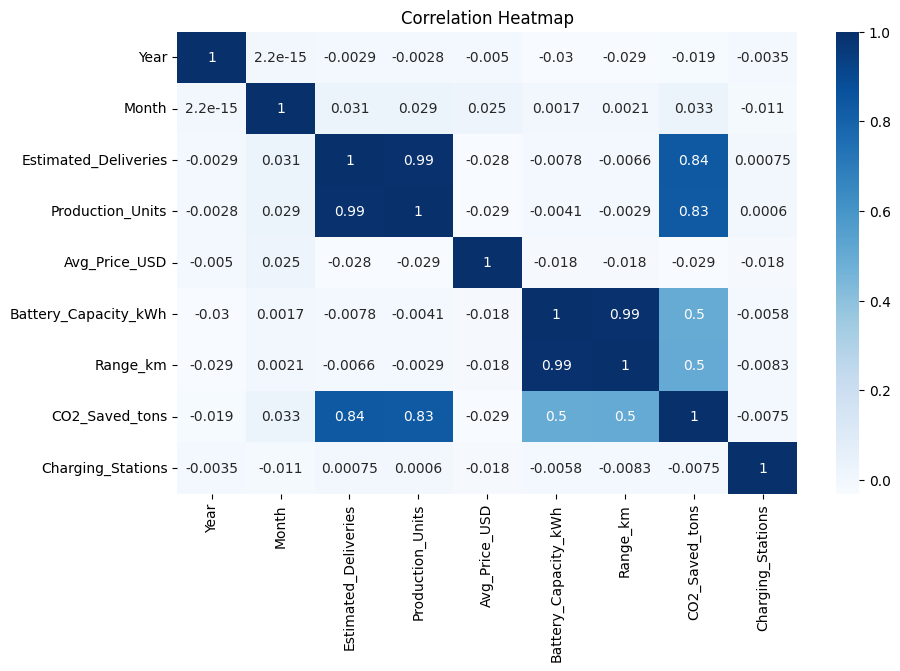

In [10]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='Blues'
)

plt.title("Correlation Heatmap")

plt.show()

### EDA Observation

The visualizations show that production units and estimated deliveries have a strong positive relationship. The heatmap also indicates correlation between several numerical features, which can help in predictive modeling.

# Feature Engineering

In [11]:
df['Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' + df['Month'].astype(str)
)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01


### Sorting Data Based on Date

In [14]:
df = df.sort_values('Date')

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
872,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01
1766,2015,1,Europe,Model S,4350,4736,53251.53,82,475,309.94,Interpolated (Month),5046,2015-01-01
2354,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01
2312,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01
2293,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01


### Creating Lag Feature

In [17]:
df['Previous_Deliveries'] = df['Estimated_Deliveries'].shift(1)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Previous_Deliveries
872,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01,NaN
1766,2015,1,Europe,Model S,4350,4736,53251.53,82,475,309.94,Interpolated (Month),5046,2015-01-01,12446.0
2354,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01,4350.0
2312,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01,11446.0
2293,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01,8803.0


In [18]:
df.dropna(inplace=True)

print("Null values removed successfully")

df.head()

Null values removed successfully


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Previous_Deliveries
1766,2015,1,Europe,Model S,4350,4736,53251.53,82,475,309.94,Interpolated (Month),5046,2015-01-01,12446.0
2354,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01,4350.0
2312,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01,11446.0
2293,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01,8803.0
2215,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01,6367.0


# Model Training

In [21]:
df['Rolling_Mean'] = df['Estimated_Deliveries'].rolling(window=3).mean()

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Previous_Deliveries,Rolling_Mean
1766,2015,1,Europe,Model S,4350,4736,53251.53,82,475,309.94,Interpolated (Month),5046,2015-01-01,12446.0,NaN
2354,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01,4350.0,NaN
2312,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01,11446.0,8199.666667
2293,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01,8803.0,8872.000000
2215,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01,6367.0,7988.333333


In [22]:
df.dropna(inplace=True)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Previous_Deliveries,Rolling_Mean
2312,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01,11446.0,8199.666667
2293,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01,8803.0,8872.000000
2215,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01,6367.0,7988.333333
2023,2015,1,North America,Model S,11986,13302,91906.09,82,457,821.64,Estimated (Region),4871,2015-01-01,8795.0,9049.333333
1872,2015,1,Europe,Model X,8833,8878,113652.43,82,461,610.80,Official (Quarter),10950,2015-01-01,11986.0,9871.333333


In [23]:
X = df[['Production_Units', 'Previous_Deliveries', 'Rolling_Mean']]

y = df['Estimated_Deliveries']

print("Features and target variable selected")

Features and target variable selected


### Splitting the Dataset

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (2109, 3)
Testing data shape: (528, 3)


### Training Linear Regression Model

In [25]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


### Model Prediction

In [26]:
y_pred = model.predict(X_test)

print("Predictions generated successfully")

Predictions generated successfully


# Model Evaluation

In [27]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

print("R2 Score:", r2_score(y_test, y_pred))

MAE: 360.0788523955043
RMSE: 442.55441727736843
R2 Score: 0.9876380359713661


# Forecasting and Trend Analysis

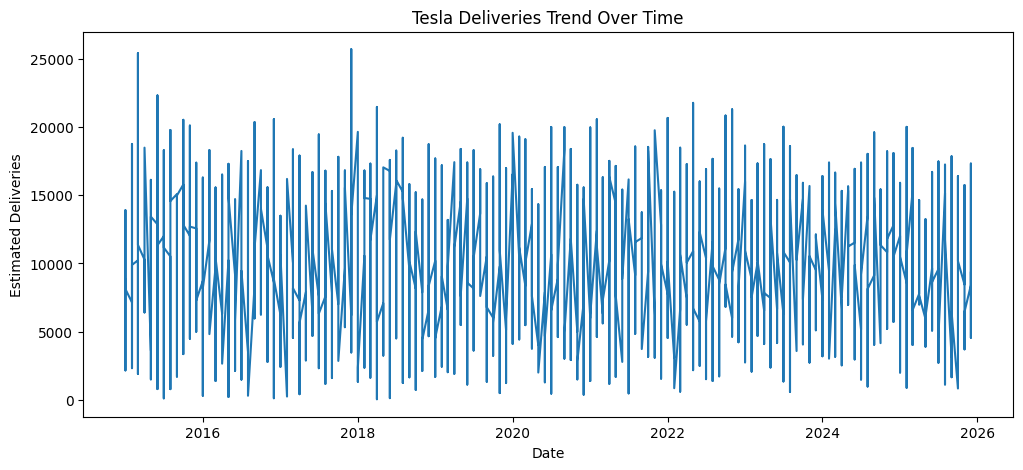

In [28]:
plt.figure(figsize=(12,5))

plt.plot(
    df['Date'],
    df['Estimated_Deliveries']
)

plt.title("Tesla Deliveries Trend Over Time")

plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")

plt.show()

### Forecasting Observation

The trend graph shows fluctuations in Tesla deliveries over different time periods. Overall, the deliveries show a gradual increasing trend, which indicates growth in production and market demand.

# Conclusion

In this project, an end-to-end machine learning pipeline was built using Tesla sales and production data. Different stages such as data understanding, exploratory data analysis, feature engineering, model training, and evaluation were performed successfully.

A Linear Regression model was trained to predict estimated deliveries using engineered features. Basic forecasting concepts such as lag features and rolling mean were also applied for trend analysis.

# Future Improvements

- More advanced forecasting techniques can be applied.
- Additional features can improve model accuracy.